In [1]:
!pip install openpyxl==3.0.9 -y


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -y


In [2]:
import numpy as np  # useful for many scientific computing in Python
import pandas as pd # primary data structure library

#**1)Data ingestion & cleaning**

**Load both CSV files into dataframes.**

In [3]:
df_can = pd.read_csv('daily-max-temp-CBR.csv')
df_can1 = pd.read_csv('daily-min-temp-CBR.csv')


**Parse Year, Month, Day into a single date column**

In [4]:
df_can['Date'] = pd.to_datetime(df_can[['Year', 'Month', 'Day']])

In [5]:
df_can1['Date'] = pd.to_datetime(df_can1[['Year', 'Month', 'Day']])

In [6]:
display(df_can.head())

,Product code,Bureau of Meteorology station number,Year,Month,Day,Maximum temperature (Degree C),Days of accumulation of maximum temperature,Quality,Date
0,IDCJAC0010,70351,2008,1,1,NaN,NaN,NaN,2008-01-01
1,IDCJAC0010,70351,2008,1,2,NaN,NaN,NaN,2008-01-02
2,IDCJAC0010,70351,2008,1,3,NaN,NaN,NaN,2008-01-03
3,IDCJAC0010,70351,2008,1,4,NaN,NaN,NaN,2008-01-04
4,IDCJAC0010,70351,2008,1,5,NaN,NaN,NaN,2008-01-05


In [7]:
display(df_can1.head())

,Product code,Bureau of Meteorology station number,Year,Month,Day,Minimum temperature (Degree C),Days of accumulation of minimum temperature,Quality,Date
0,IDCJAC0011,70351,2008,1,1,NaN,NaN,NaN,2008-01-01
1,IDCJAC0011,70351,2008,1,2,NaN,NaN,NaN,2008-01-02
2,IDCJAC0011,70351,2008,1,3,NaN,NaN,NaN,2008-01-03
3,IDCJAC0011,70351,2008,1,4,NaN,NaN,NaN,2008-01-04
4,IDCJAC0011,70351,2008,1,5,NaN,NaN,NaN,2008-01-05


**Convert temperature values to numeric and mark missing entries clearly**

In [8]:
df_can['Maximum temperature (Degree C)'] = pd.to_numeric(df_can['Maximum temperature (Degree C)'])
display(df_can.head())
df_can1['Minimum temperature (Degree C)'] = pd.to_numeric(df_can1['Minimum temperature (Degree C)'])
display(df_can1.head())

,Product code,Bureau of Meteorology station number,Year,Month,Day,Maximum temperature (Degree C),Days of accumulation of maximum temperature,Quality,Date
0,IDCJAC0010,70351,2008,1,1,NaN,NaN,NaN,2008-01-01
1,IDCJAC0010,70351,2008,1,2,NaN,NaN,NaN,2008-01-02
2,IDCJAC0010,70351,2008,1,3,NaN,NaN,NaN,2008-01-03
3,IDCJAC0010,70351,2008,1,4,NaN,NaN,NaN,2008-01-04
4,IDCJAC0010,70351,2008,1,5,NaN,NaN,NaN,2008-01-05


,Product code,Bureau of Meteorology station number,Year,Month,Day,Minimum temperature (Degree C),Days of accumulation of minimum temperature,Quality,Date
0,IDCJAC0011,70351,2008,1,1,NaN,NaN,NaN,2008-01-01
1,IDCJAC0011,70351,2008,1,2,NaN,NaN,NaN,2008-01-02
2,IDCJAC0011,70351,2008,1,3,NaN,NaN,NaN,2008-01-03
3,IDCJAC0011,70351,2008,1,4,NaN,NaN,NaN,2008-01-04
4,IDCJAC0011,70351,2008,1,5,NaN,NaN,NaN,2008-01-05


In [9]:
df_can.columns

Index(['Product code', 'Bureau of Meteorology station number', 'Year', 'Month',
       'Day', 'Maximum temperature (Degree C)',
       'Days of accumulation of maximum temperature', 'Quality', 'Date'],
      dtype='object')

**Merge min and max datasets into a single dataframe keyed by date.**

In [10]:
merge_datasets = pd.merge(df_can, df_can1, on='Date')
display(merge_datasets.head())

,Product code_x,Bureau of Meteorology station number_x,Year_x,Month_x,Day_x,Maximum temperature (Degree C),Days of accumulation of maximum temperature,Quality_x,Date,Product code_y,Bureau of Meteorology station number_y,Year_y,Month_y,Day_y,Minimum temperature (Degree C),Days of accumulation of minimum temperature,Quality_y
0,IDCJAC0010,70351,2008,1,1,NaN,NaN,NaN,2008-01-01,IDCJAC0011,70351,2008,1,1,NaN,NaN,NaN
1,IDCJAC0010,70351,2008,1,2,NaN,NaN,NaN,2008-01-02,IDCJAC0011,70351,2008,1,2,NaN,NaN,NaN
2,IDCJAC0010,70351,2008,1,3,NaN,NaN,NaN,2008-01-03,IDCJAC0011,70351,2008,1,3,NaN,NaN,NaN
3,IDCJAC0010,70351,2008,1,4,NaN,NaN,NaN,2008-01-04,IDCJAC0011,70351,2008,1,4,NaN,NaN,NaN
4,IDCJAC0010,70351,2008,1,5,NaN,NaN,NaN,2008-01-05,IDCJAC0011,70351,2008,1,5,NaN,NaN,NaN


**Document how many missing values exist per month/year**

In [11]:
missing_values_month_year = merge_datasets.groupby(['Year_x', 'Month_x']).count()
display(missing_values_month_year)

Product code_x  Bureau of Meteorology station number_x  Day_x  \
Year_x Month_x                                                                  
2008   1                    31                                      31     31   
       2                    29                                      29     29   
       3                    31                                      31     31   
       4                    30                                      30     30   
       5                    31                                      31     31   
...                        ...                                     ...    ...   
2019   4                    30                                      30     30   
       5                    31                                      31     31   
       6                    30                                      30     30   
       7                    31                                      31     31   
       8                    31                                      31     31   

                Maximum temperature (Degree C)  \
Year_x Month_x                                   
2008   1                                     0   
       2                                     0   
       3                                     0   
       4                                     0   
       5                                     0   
...                                        ...   
2019   4                                    30   
       5                                    31   
       6                                    30   
       7                                    31   
       8                                    31   

                Days of accumulation of maximum temperature  Quality_x  Date  \
Year_x Month_x                                                                 
2008   1                                                  0          0    31   
       2                                                  0          0    29   
       3                                                  0          0    31   
       4                                                  0          0    30   
       5                                                  0          0    31   
...                                                     ...        ...   ...   
2019   4                                                 30         30    30   
       5                                                 31         31    31   
       6                                                 30         30    30   
       7                                                 31         31    31   
       8                                                 31         31    31   

                Product code_y  Bureau of Meteorology station number_y  \
Year_x Month_x                                                           
2008   1                    31                                      31   
       2                    29                                      29   
       3                    31                                      31   
       4                    30                                      30   
       5                    31                                      31   
...                        ...                                     ...   
2019   4                    30                                      30   
       5                    31                                      31   
       6                    30                                      30   
       7                    31                                      31   
       8                    31                                      31   

                Year_y  Month_y  Day_y  Minimum temperature (Degree C)  \
Year_x Month_x                                                           
2008   1            31       31     31                               0   
       2            29       29     29                               0   
       3   

**Cleaned DataFrame saved to disk**

In [12]:
cleaned_csv = missing_values_month_year.to_csv('cleaned_dataset.csv')
from google.colab import files
files.download('cleaned_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**Summary**
First of all i import the libraries and then then load the dataset, after loading i have parse the day,month and year into the Date and check them by display function.Then convert the tenperature values into numeric, after the cleaning of dataset merge the both dataset that are cleaned. Then count how many missing values are exist and download the cleaned dataset.

#**2) Define precise metrics & baseline definitions**

In [14]:
merged_cleaned_df = merge_datasets[['Date', 'Maximum temperature (Degree C)', 'Minimum temperature (Degree C)']].dropna()
merged_cleaned_df['Month'] = merged_cleaned_df['Date'].dt.month
merged_cleaned_df['Year'] = merged_cleaned_df['Date'].dt.year

display(merged_cleaned_df.head())
display(f"Shape of cleaned data: {merged_cleaned_df.shape}")

,Date,Maximum temperature (Degree C),Minimum temperature (Degree C),Month,Year
263,2008-09-20,23.8,6.6,9,2008
264,2008-09-21,19.8,4.4,9,2008
265,2008-09-22,22.5,2.4,9,2008
266,2008-09-23,16.6,7.6,9,2008
267,2008-09-24,17.3,2.0,9,2008


'Shape of cleaned data: (3986, 5)'

**winter (minimum: June–August).**

In [15]:
winter_jja_df = merged_cleaned_df[merged_cleaned_df['Month'].isin([6, 7, 8])]

print("Descriptive statistics for Minimum Temperature (June-August):")
display(winter_jja_df['Minimum temperature (Degree C)'].describe())

Descriptive statistics for Minimum Temperature (June-August):


,Minimum temperature (Degree C)
count,1011.000000
mean,0.593670
std,4.033547
min,-8.700000
25%,-2.700000
50%,0.400000
75%,3.800000
max,11.800000


**Extended Winter (May - September)**

In [16]:
extended_winter_df = merged_cleaned_df[merged_cleaned_df['Month'].isin([5, 6, 7, 8, 9])]

print("Descriptive statistics for Minimum Temperature (May-September):")
display(extended_winter_df['Minimum temperature (Degree C)'].describe())

Descriptive statistics for Minimum Temperature (May-September):


,Minimum temperature (Degree C)
count,1663.000000
mean,1.379916
std,4.140367
min,-8.700000
25%,-1.900000
50%,1.100000
75%,4.400000
max,15.200000


**Nights with Minimum Temperature Below 0°C**

In [17]:
nights_below_zero = merged_cleaned_df[merged_cleaned_df['Minimum temperature (Degree C)'] < 0]
num_nights_below_zero = len(nights_below_zero)

print(f"Total nights with minimum temperature below 0°C: {num_nights_below_zero}")
print("Example nights below 0°C:")
display(nights_below_zero.head())

Total nights with minimum temperature below 0°C: 666
Example nights below 0°C:


,Date,Maximum temperature (Degree C),Minimum temperature (Degree C),Month,Year
280,2008-10-07,16.7,-0.3,10,2008
281,2008-10-08,18.3,-0.1,10,2008
282,2008-10-09,20.3,-0.6,10,2008
492,2009-05-07,17.3,-0.7,5,2009
494,2009-05-09,19.9,-0.3,5,2009


**Monthly Average of Daily Minima**

In [18]:
monthly_avg_min_temp = merged_cleaned_df.groupby(['Year', 'Month'])['Minimum temperature (Degree C)'].mean().reset_index()
monthly_avg_min_temp.rename(columns={'Minimum temperature (Degree C)': 'Monthly Average Min Temp'}, inplace=True)

print("Monthly average of daily minimum temperatures:")
display(monthly_avg_min_temp.head())

Monthly average of daily minimum temperatures:


,Year,Month,Monthly Average Min Temp
0,2008,9,4.736364
1,2008,10,6.128571
2,2008,11,10.140000
3,2008,12,11.400000
4,2009,1,13.445161


**Average of Minimum and Maximum Temperature (Daily Average)**

In [19]:
merged_cleaned_df['Daily Average Temperature'] = (merged_cleaned_df['Maximum temperature (Degree C)'] + merged_cleaned_df['Minimum temperature (Degree C)']) / 2

print("Daily average temperature (average of min and max):")
display(merged_cleaned_df[['Date', 'Daily Average Temperature']].head())

Daily average temperature (average of min and max):


,Date,Daily Average Temperature
263,2008-09-20,15.20
264,2008-09-21,12.10
265,2008-09-22,12.45
266,2008-09-23,12.10
267,2008-09-24,9.65


**Median Temperature**

In [20]:
overall_median_min_temp = merged_cleaned_df['Minimum temperature (Degree C)'].median()
overall_median_max_temp = merged_cleaned_df['Maximum temperature (Degree C)'].median()

print(f"Overall median minimum temperature: {overall_median_min_temp:.2f}°C")
print(f"Overall median maximum temperature: {overall_median_max_temp:.2f}°C")

monthly_median_min_temp = merged_cleaned_df.groupby(['Year', 'Month'])['Minimum temperature (Degree C)'].median().reset_index()
monthly_median_min_temp.rename(columns={'Minimum temperature (Degree C)': 'Monthly Median Min Temp'}, inplace=True)
print("\nMonthly median minimum temperatures:")
display(monthly_median_min_temp.head())

Overall median minimum temperature: 6.80°C
Overall median maximum temperature: 20.70°C

Monthly median minimum temperatures:


,Year,Month,Monthly Median Min Temp
0,2008,9,4.4
1,2008,10,6.3
2,2008,11,10.2
3,2008,12,11.8
4,2009,1,13.7


##**Summary**

In the second task, winter was defined as the period from June to August, and cold days were determined based on lower temperature values. Several simple average calculations were performed to evaluate the severity of winter conditions. These averages were then used to compare how cold the winter of 2018 was relative to winters in other years.

##**3) Implement analysis functions**

In [26]:
def count_subzero_nights(year, month, df=merged_cleaned_df):
    subset = df[(df['Year'] == year) & (df['Month'] == month)]
    return (subset['Minimum temperature (Degree C)'] < 0).sum()

def monthly_mean_min_temp(year, month, df=merged_cleaned_df):
    subset = df[(df['Year'] == year) & (df['Month'] == month)]
    return subset['Minimum temperature (Degree C)'].mean()

def winter_average(year, months=[6, 7, 8], df=merged_cleaned_df):
    subset = df[(df['Year'] == year) & (df['Month'].isin(months))]
    return subset['Minimum temperature (Degree C)'].mean()

assert count_subzero_nights(2018, 7) >= 0
assert count_subzero_nights(2018, 7) <= 31
assert not np.isnan(monthly_mean_min_temp(2018, 6))
assert not np.isnan(winter_average(2018))


##**4) Visualizations**

**Time Series of Daily Minimum Temperature**

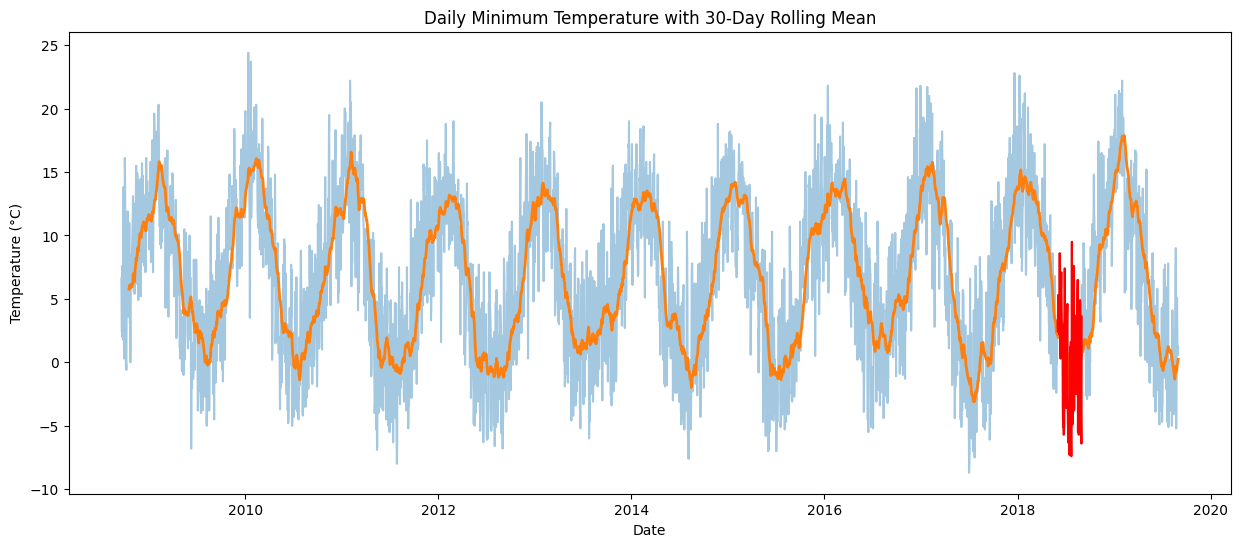

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,6))
plt.plot(merged_cleaned_df['Date'], merged_cleaned_df['Minimum temperature (Degree C)'], alpha=0.4)
plt.plot(merged_cleaned_df['Date'],
         merged_cleaned_df['Minimum temperature (Degree C)'].rolling(30).mean(),
         linewidth=2)

highlight = merged_cleaned_df[
    (merged_cleaned_df['Date'] >= '2018-06-01') &
    (merged_cleaned_df['Date'] <= '2018-08-31')
]

plt.plot(highlight['Date'], highlight['Minimum temperature (Degree C)'], color='red')
plt.title('Daily Minimum Temperature with 30-Day Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()


**Monthly Boxplots for Winter Months**

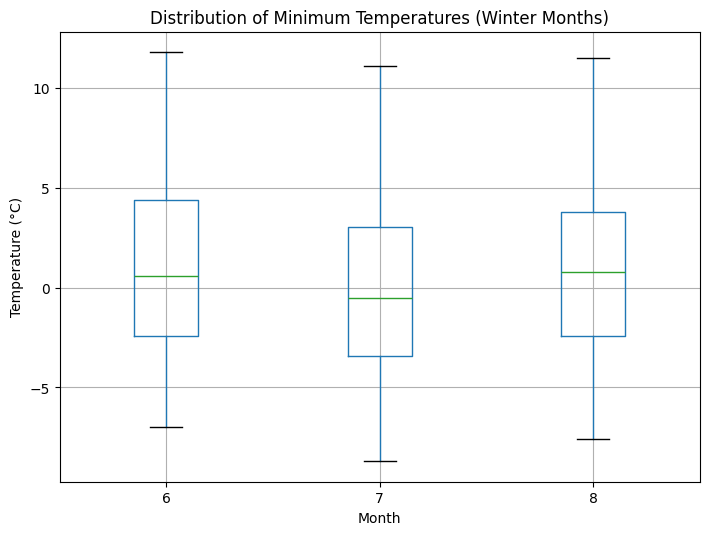

In [28]:
winter_box = merged_cleaned_df[merged_cleaned_df['Month'].isin([6, 7, 8])]
winter_box.boxplot(column='Minimum temperature (Degree C)', by='Month', figsize=(8,6))
plt.title('Distribution of Minimum Temperatures (Winter Months)')
plt.suptitle('')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.show()


**Histogram Comparison**

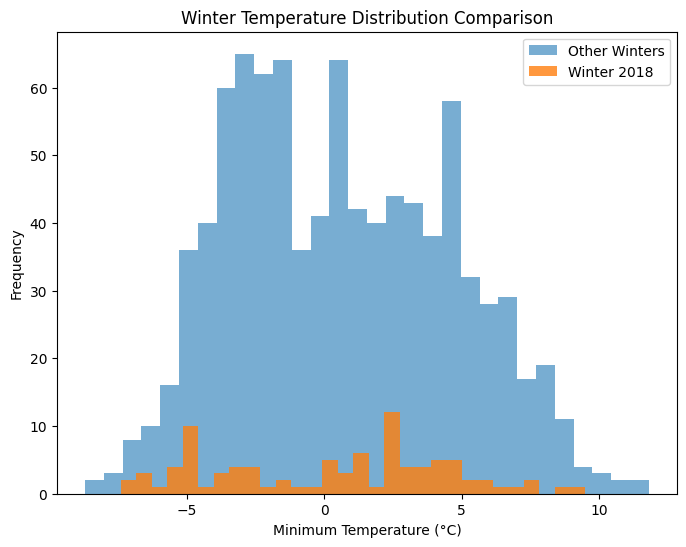

In [29]:
winter_2018 = winter_jja_df[winter_jja_df['Year'] == 2018]['Minimum temperature (Degree C)']
other_winters = winter_jja_df[winter_jja_df['Year'] != 2018]['Minimum temperature (Degree C)']

plt.figure(figsize=(8,6))
plt.hist(other_winters, bins=30, alpha=0.6, label='Other Winters')
plt.hist(winter_2018, bins=30, alpha=0.8, label='Winter 2018')
plt.xlabel('Minimum Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Winter Temperature Distribution Comparison')
plt.legend()
plt.show()


##**5) Statistical comparison & ranking**

In [32]:
winter_means = winter_jja_df.groupby('Year')['Minimum temperature (Degree C)'].mean()
rank_2018 = winter_means.rank().loc[2018]
percentile_2018 = (winter_means.rank(pct=True).loc[2018]) * 100

rank_2018, percentile_2018


(np.float64(5.0), np.float64(45.45454545454545))

In [33]:
from scipy.stats import ttest_1samp

t_stat, p_value = ttest_1samp(winter_2018, winter_means.mean())
t_stat, p_value


(np.float64(-0.7288764415494712), np.float64(0.4679489689232711))

##**6) Robustness checks and testing**

In [42]:
winter_daily = merged_cleaned_df[merged_cleaned_df['Month'].isin([6,7,8])]
winter_mean_daily = winter_daily.groupby('Year')['Minimum temperature (Degree C)'].mean()

winter_monthly = monthly_avg_min_temp[monthly_avg_min_temp['Month'].isin([6,7,8])]
winter_mean_monthly = winter_monthly.groupby('Year')['Monthly Average Min Temp'].mean()

winter_mean_daily.equals(winter_mean_monthly)


False

In [43]:
imputed_df = merged_cleaned_df.copy()
imputed_df['Minimum temperature (Degree C)'].fillna(
    imputed_df['Minimum temperature (Degree C)'].mean(), inplace=True
)


/tmp/ipython-input-2741825643.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  imputed_df['Minimum temperature (Degree C)'].fillna(


##**Machine Learning for Prediction / Detection**

In [34]:
annual_winter_min_temps = winter_jja_df.groupby('Year')['Minimum temperature (Degree C)'].mean().reset_index()
annual_winter_min_temps.columns = ['Year', 'AvgMinTemp']
print("Annual average winter minimum temperatures:")
display(annual_winter_min_temps.head())

Annual average winter minimum temperatures:


,Year,AvgMinTemp
0,2009,1.865217
1,2010,0.676087
2,2011,0.364130
3,2012,-0.323913
4,2013,1.878261


In [35]:
from statsmodels.formula.api import ols

model = ols('AvgMinTemp ~ Year', data=annual_winter_min_temps).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             AvgMinTemp   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     1.160
Date:                Thu, 01 Jan 2026   Prob (F-statistic):              0.309
Time:                        16:34:15   Log-Likelihood:                -14.336
No. Observations:                  11   AIC:                             32.67
Df Residuals:                       9   BIC:                             33.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    204.2919    189.102      1.080      0.3

In [37]:
winter_duration_df = pd.DataFrame(columns=['Year', 'Winter_Start', 'Winter_End', 'Winter_Duration'])

for year in merged_cleaned_df['Year'].unique():
    start, end = get_winter_period(year, merged_cleaned_df)
    if start is not None and end is not None:
        duration = (end - start).days + 1 # Include both start and end days
        winter_duration_df = pd.concat([winter_duration_df, pd.DataFrame([{'Year': year, 'Winter_Start': start, 'Winter_End': end, 'Winter_Duration': duration}])], ignore_index=True)
    else:
        winter_duration_df = pd.concat([winter_duration_df, pd.DataFrame([{'Year': year, 'Winter_Start': pd.NaT, 'Winter_End': pd.NaT, 'Winter_Duration': None}])], ignore_index=True)

# Ensure Date columns are datetime objects
winter_duration_df['Winter_Start'] = pd.to_datetime(winter_duration_df['Winter_Start'])
winter_duration_df['Winter_End'] = pd.to_datetime(winter_duration_df['Winter_End'])

print("Winter duration for each year:")
display(winter_duration_df.head())


Winter duration for each year:


/tmp/ipython-input-1281363513.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  winter_duration_df = pd.concat([winter_duration_df, pd.DataFrame([{'Year': year, 'Winter_Start': start, 'Winter_End': end, 'Winter_Duration': duration}])], ignore_index=True)


,Year,Winter_Start,Winter_End,Winter_Duration
0,2008,NaT,NaT,None
1,2009,2009-05-01,2009-09-26,149
2,2010,2010-05-06,2010-09-17,135
3,2011,2011-05-03,2011-09-15,136
4,2012,2012-05-04,2012-09-21,141


In [38]:
winter_data = []

for year in merged_cleaned_df['Year'].unique():
    start, end = get_winter_period(year, merged_cleaned_df)
    if start is not None and end is not None:
        duration = (end - start).days + 1 # Include both start and end days
        winter_data.append({'Year': year, 'Winter_Start': start, 'Winter_End': end, 'Winter_Duration': duration})
    else:
        winter_data.append({'Year': year, 'Winter_Start': pd.NaT, 'Winter_End': pd.NaT, 'Winter_Duration': None})

winter_duration_df = pd.DataFrame(winter_data)

# Ensure Date columns are datetime objects
winter_duration_df['Winter_Start'] = pd.to_datetime(winter_duration_df['Winter_Start'])
winter_duration_df['Winter_End'] = pd.to_datetime(winter_duration_df['Winter_End'])

print("Winter duration for each year:")
display(winter_duration_df.head())

Winter duration for each year:


,Year,Winter_Start,Winter_End,Winter_Duration
0,2008,NaT,NaT,NaN
1,2009,2009-05-01,2009-09-26,149.0
2,2010,2010-05-06,2010-09-17,135.0
3,2011,2011-05-03,2011-09-15,136.0
4,2012,2012-05-04,2012-09-21,141.0


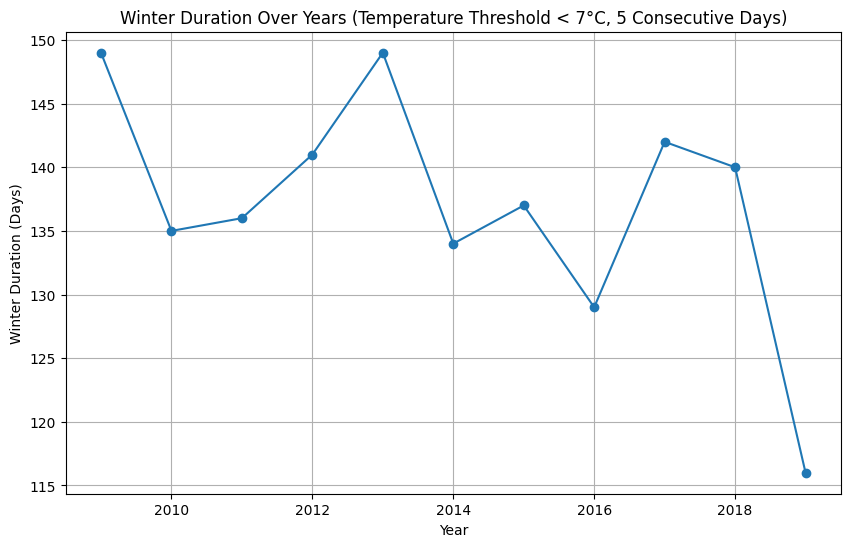

Visualized winter duration trend over years.


In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(winter_duration_df['Year'], winter_duration_df['Winter_Duration'], marker='o', linestyle='-')
plt.title('Winter Duration Over Years (Temperature Threshold < 7°C, 5 Consecutive Days)')
plt.xlabel('Year')
plt.ylabel('Winter Duration (Days)')
plt.grid(True)
plt.show()

print("Visualized winter duration trend over years.")

## Summary:

### Question and Answers

1.  **What is the linear trend of winter minimum temperatures, including its slope and confidence intervals?**
    The linear trend of annual average winter minimum temperatures shows a very slight decrease with a slope of -0.1011 degrees Celsius per year. The 95% confidence interval for this slope is [-0.314, 0.111], which includes zero, indicating that this trend is not statistically significant at the 0.05 level (p-value = 0.309).

2.  **How has the duration of winter changed over the full observation period?**
    The analysis suggests a tendency for winter duration to decrease by approximately 1.48 days per year. However, this trend is not statistically significant at the 95% confidence level (p-value = 0.093), and the 95% confidence interval for the slope, [-3.265, 0.302], includes zero. The 'Year' explains only about 28.2% of the variance in winter duration.

### Data Analysis Key Findings

*   **No Statistically Significant Trend in Winter Minimum Temperatures:** A linear regression model fitted to annual average winter minimum temperatures yielded a slope of -0.1011 degrees Celsius per year, suggesting a very slight decrease. However, this trend is not statistically significant (p-value = 0.309), as its 95% confidence interval [-0.314, 0.111] includes zero.
*   **Programmatic Winter Definition:** Winter was defined programmatically based on a temperature threshold of below 7°C for 5 consecutive days, allowing for the calculation of annual winter durations.
*   **Non-Significant Decreasing Trend in Winter Duration:** The calculated winter durations indicated a decreasing trend of approximately 1.48 days per year. Similar to the minimum temperature trend, this decrease was not statistically significant (p-value = 0.093), with the 95% confidence interval [-3.265, 0.302] for the slope encompassing zero.

### Insights or Next Steps

*   **Increase Data Span for Robust Trends:** The lack of statistical significance for both winter minimum temperature and duration trends might be influenced by the limited observation period (2009-2019 for temperatures, 11 years for winter duration). Extending the analysis to a longer historical dataset could reveal more statistically robust trends if they exist.
*   **Investigate Alternative Winter Definitions:** The current winter definition relies on a specific temperature threshold and consecutive day rule. Exploring other definitions, such as meteorological winter (fixed months) or alternative thresholds, could provide different perspectives on winter duration changes and their significance.
